In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from math import sqrt

def calcular_distancia(p1: tuple[float,float], p2: tuple[float, float]):
    x = (p2[0] - p1[0])**2
    y = (p2[1] - p1[1])**2
    resultado = sqrt(x+y)
    return resultado

p1 = (2,5)
p2 = (5,7)
r = calcular_distancia(p1,p2)
print(f"{r:.5f}")

3.60555


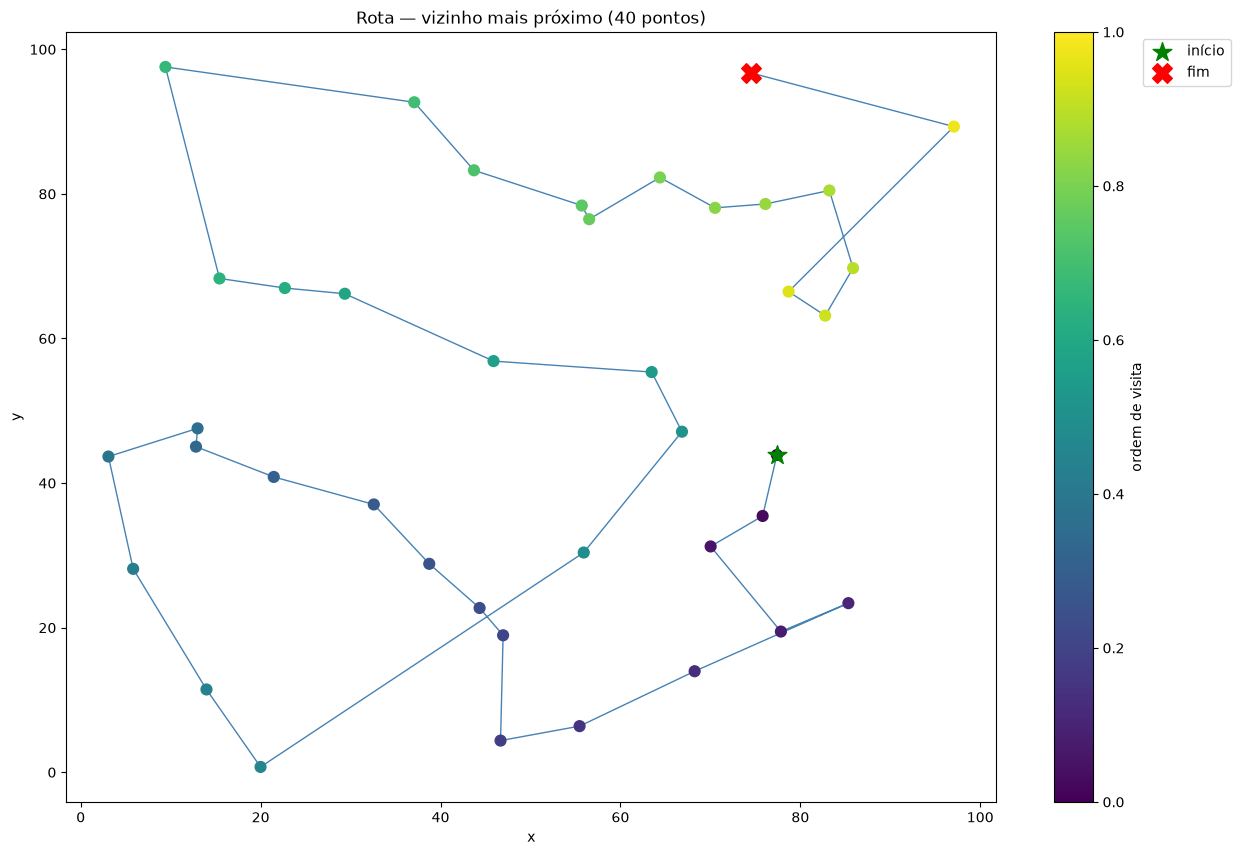

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from domain.location import Point
from domain.route_calculator import RouteCalculator

rng = np.random.default_rng(seed=42)
n_points = 40
coords = rng.uniform(low=0, high=100, size=(n_points, 2))
points = [Point(x, y) for x, y in coords]

calc = RouteCalculator(points)
route = calc.nearest_neighbor()
total = calc.total_distance() 


route_coords = np.array([p.coordinate for p in route])

plt.figure(figsize=(15, 10))
plt.plot(route_coords[:, 0], route_coords[:, 1], '-', color='steelblue', linewidth=1, zorder=1)
plt.scatter(route_coords[:, 0], route_coords[:, 1], c=range(n_points), cmap='viridis', s=60, zorder=2)
plt.scatter(*route_coords[0], c='green', s=200, marker='*', label='início', zorder=3)
plt.scatter(*route_coords[-1], c='red', s=200, marker='X', label='fim', zorder=3)

plt.colorbar(label='ordem de visita')
plt.legend(bbox_to_anchor=(1.15, 1), loc='upper left')
plt.title(f'Rota — vizinho mais próximo ({n_points} pontos)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


In [12]:
optimized_calc = RouteCalculator(route)
optimized_total = optimized_calc.total_distance()
print(f"Distância original (ordem de entrada): {calc.total_distance():.2f}")
print(f"Distância otimizada (vizinho mais próximo): {optimized_total:.2f}")

Distância original (ordem de entrada): 1883.64
Distância otimizada (vizinho mais próximo): 518.13
